In [1]:
#### Checking against Jerry's stuff
import sys

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import esmpy as E

workdir_ = '/glade/work/juliob'
if ( workdir_ not in sys.path ):
    sys.path.append(workdir_)
    print( f" a path to {workdir_} added in {__name__} ")

#from ReanalysisRegrid_dev.Drivers.Utils import GridUtils as GrU 

from PyRegridding.Drivers import RegridField as RgF
from PyRegridding.Utils import GridUtils as GrU 

import importlib
importlib.reload(GrU)


 PyRegridding.Utils.MyConstants in /glade/work/juliob/PyRegridding/Utils 
Using Flexible parallel/serial VertRegrid 
 PyRegridding.Utils.MyConstants in /glade/work/juliob/PyRegridding/Utils 


<module 'PyRegridding.Utils.GridUtils' from '/glade/work/juliob/PyRegridding/Utils/GridUtils.py'>

In [2]:
target_file = '/glade/campaign/cesm/development/espwg/SMYLE-ERA5-L83/inputdata/cesm2_init/b.e21.SMYLE_ERA5_L83_IC.f09_g17.1997-11.01/1997-11-01/b.e21.SMYLE_ERA5_L83_IC.f09_g17.1997-11.01.cam.i.1997-11-01-00000.nc'
#target_file = '/glade/derecho/scratch/juliob/era5-testing/fv1x1/L58/ERA5_x_fv1x1_L58_rgC1_WO.1997-11-01-00000.nc'
target_file = '/glade/derecho/scratch/juliob/era5-linear-vint/fv1x1/L58/ERA5_x_fv1x1_L58_rgC1_WO.1997-11-01-00000.nc'

new_file = '/glade/derecho/scratch/juliob/era5-debugging/out-of-the-box//fv1x1/L83/ERA5_x_fv1x1_L83_rgC1_WO.1997-11-01-00000.nc'
#new_file = '/glade/derecho/scratch/juliob/era5-debugging/ps_cam_change//fv1x1/L83/ERA5_x_fv1x1_L83_rgC1_WO.1997-11-01-00000.nc'
#new_file = '/glade/derecho/scratch/juliob/era5-debugging/linear_T_vinterp//fv1x1/L83/ERA5_x_fv1x1_L83_rgC1_WO.1997-11-01-00000.nc'
#new_file = '/glade/derecho/scratch/juliob/era5-debugging/back-to-square-1//fv1x1/L83/ERA5_x_fv1x1_L83_rgC1_WO.1997-11-01-00000.nc'
#new_file = '/glade/derecho/scratch/juliob/era5-debugging/serial-vinterp//fv1x1/L83/ERA5_x_fv1x1_L83_rgC1_WO.1997-11-01-00000.nc'
X0 = xr.open_dataset(target_file ,  decode_times=False )

X1 = xr.open_dataset(new_file)




era5dir = "/glade/campaign/collections/rda/data/ds633.6/e5.oper.an.ml/" # "/glade/campaign/collections/rda/data/ds633.0/e5.oper.an.pl"
era5dir = "/glade/campaign/collections/rda/data/ds633.0/e5.oper.an.pl/"

year,month,day,hour0 = 1997,11,1,0

monStr=str( year ).zfill(4)+str(month).zfill(2)

hour1=hour0+23
ymdh0=str( year ).zfill(4)+str(month).zfill(2)+str(day).zfill(2)+str(hour0).zfill(2)
ymdh1=str( year ).zfill(4)+str(month).zfill(2)+str(day).zfill(2)+str(hour1).zfill(2)
ymdh=ymdh0+'_'+ymdh1

wrkdir=era5dir+monStr+"/"


# e5.oper.an.pl.128_130_t.ll025sc.1997110100_1997110123.nc

tfile = wrkdir + 'e5.oper.an.pl.128_130_t.ll025sc.' + ymdh + '.nc'
print( tfile )
T_ERA   = xr.open_mfdataset( tfile , data_vars='different', coords='different')


####0#############################################
# Extract ERA5 temperature and pressure levels.
#################################################
te_era_pl = T_ERA.T.values
pl_era = 100. * T_ERA.level.values



/glade/campaign/collections/rda/data/ds633.0/e5.oper.an.pl/199711/e5.oper.an.pl.128_130_t.ll025sc.1997110100_1997110123.nc


In [3]:

############################
# Initialize dict for regridding
############################
RgObs={}
Src='ERA5'
Dst='fv1x1'

# Make regridding objects for ERA5 640x1280 to fv1x1
RegridObj = GrU.regrid_object_lib(RgOb=RgObs, src=Src, dst=Dst, RegridMethod='CONSERVE' )

# Make regridding objects for ERA5 720x1440 to fv1x1
RegridObj = GrU.regrid_object_lib(RgOb=RgObs, src='ERA5_720x1440', dst=Dst, RegridMethod='CONSERVE' )


ERA5_x_fv1x1_CONSERVE will be created !!!!
Got monikers ERA5 and fv1x1 from arguments

 
 Mapping ... ERA5 -x- fv1x1 
Ready to go ... ERA5 -x- fv1x1 0.0000 seconds
Finished Grid Mesh creation  0.1718 seconds
/glade/campaign/cesm/cesmdata/cseg/inputdata/share/scripgrids/fv0.9x1.25_141008.nc 
 (288, 192)
/glade/work/juliob/ERA5-proc/ERA5interp/grids/ERA5_640x1280_scrip.nc 
 (1280, 640)
Finished dstField,srcField  0.1746 seconds
/glade/work/juliob/GridFiles/Weights/ERA5_x_fv1x1_CONSERVE.nc
Reading weights from /glade/work/juliob/GridFiles/Weights/ERA5_x_fv1x1_CONSERVE.nc 
Finished generatind Regrd from wgts file 3.5641 seconds
 Not interpolating. Returning: regrd, srcf, dstf, ERA5, fv1x1 
ERA5_720x1440_x_fv1x1_CONSERVE will be created !!!!
Got monikers ERA5_720x1440 and fv1x1 from arguments

 
 Mapping ... ERA5_720x1440 -x- fv1x1 
Ready to go ... ERA5_720x1440 -x- fv1x1 0.0000 seconds
Finished Grid Mesh creation  0.3008 seconds
/glade/campaign/cesm/cesmdata/cseg/inputdata/share/scripgrids

In [4]:
################################################
# Regrid te_era_pl (Horz=ERA5_720x1440, Vert=ERA5_pl) 
# onto CAM f09 (fv1x1) horz grid
#################################################

te_era_pl_f09 =RgF.Horz(xfld_Src=te_era_pl , Src='ERA5_720x1440', Dst=Dst , RegridObj_In= RegridObj )

print(np.shape(te_era_pl_f09))


Got monikers ERA5_720x1440 and fv1x1 from arguments

 
 Mapping ... ERA5_720x1440 -x- fv1x1 
 Getting (regrd, srcf, dstf) from argument 
Used GrU.latlon /glade/campaign/cesm/cesmdata/cseg/inputdata/share/scripgrids/fv0.9x1.25_141008.nc for lat lon 
 dstHkey=yx , ncol=0 , ny=192, nx=288 
 srcShape=tzyx, nzot=24, nz=37 
(24, 37, 192, 288)


In [5]:

te0=X0.T.values
te1=X1.T.values

ps0=X0.PS.values
ps1=X1.PS.values

hyai0 = X0.hyai.values
hyam0 = X0.hyam.values
hybi0 = X0.hybi.values
hybm0 = X0.hybm.values

hyai1 = X1.hyai.values
hyam1 = X1.hyam.values
hybi1 = X1.hybi.values
hybm1 = X1.hybm.values


hyai1 = X1.hyai.values


nt0,nz0,ny0,nx0 = np.shape( te0 )
nt1,nz1,ny1,nx1 = np.shape( te1 )

pmid0 = np.zeros( (nt0,nz0,ny0,nx0) ) 
pmid1 = np.zeros( (nt1,nz1,ny1,nx1) ) 

for t in np.arange( nt0 ):
    for z in np.arange(nz0):
        pmid0[t,z,:,:] = hyam0[z]*100_000. + hybm0[z]*ps0[t,:,:] 
for t in np.arange( nt1 ):
    for z in np.arange( nz1 ):
        pmid1[t,z,:,:] = hyam1[z]*100_000. + hybm1[z]*ps1[t,:,:] 

#plt.plot( hyai-hyai1 )

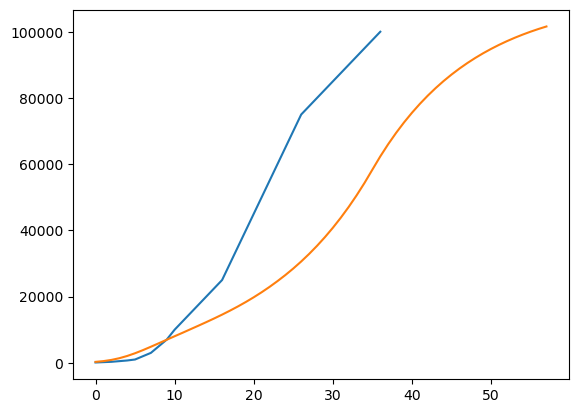

In [6]:
plt.plot( pl_era  )
plt.plot( pmid0[0,:,80,0] )

In [7]:
print( np.shape(pl_era)[0])

37


In [8]:
from scipy import interpolate as intr


################################################
# Interpolate te_era_x1 (Horz=CAM, Vert=ERA5) '
# to CAM vertical grid in eta coordinates
#################################################
nz_pl = np.shape(pl_era)[0]
te0_pl = np.zeros( (nt0,nz_pl,ny0,nx0) )
te1_pl = np.zeros( (nt1,nz_pl,ny1,nx1) )

vintkind='quadratic'
vintkind='linear'
for t in np.arange(nt0):
    for y in np.arange( ny0 ):
        for x in np.arange( nx0 ):
            pl_cam = pmid0[t,:,y,x]
            fint=intr.interp1d( x = pl_cam, y=te0[t,:,y,x] , 
                                fill_value='extrapolate', kind='quadratic'  )
            te0_pl[t,:,y,x] = fint(  pl_era )
for t in np.arange(nt1):
    for y in np.arange( ny1 ):
        for x in np.arange( nx1 ):
            pl_cam = pmid1[t,:,y,x]
            fint=intr.interp1d( x = pl_cam, y=te1[t,:,y,x] , 
                                fill_value='extrapolate', kind='quadratic'  )
            te1_pl[t,:,y,x] = fint(  pl_era )


In [9]:

print( np.shape(te0_pl) )
print( np.shape(te1_pl) )
print( np.shape(te_era_pl_f09) )
print( pl_era )


(1, 37, 192, 288)
(1, 37, 192, 288)
(24, 37, 192, 288)
[   100.    200.    300.    500.    700.   1000.   2000.   3000.   5000.
   7000.  10000.  12500.  15000.  17500.  20000.  22500.  25000.  30000.
  35000.  40000.  45000.  50000.  55000.  60000.  65000.  70000.  75000.
  77500.  80000.  82500.  85000.  87500.  90000.  92500.  95000.  97500.
 100000.]


1000.0


Text(0.5, 1.0, "Diff between Jerry's code and my code ")

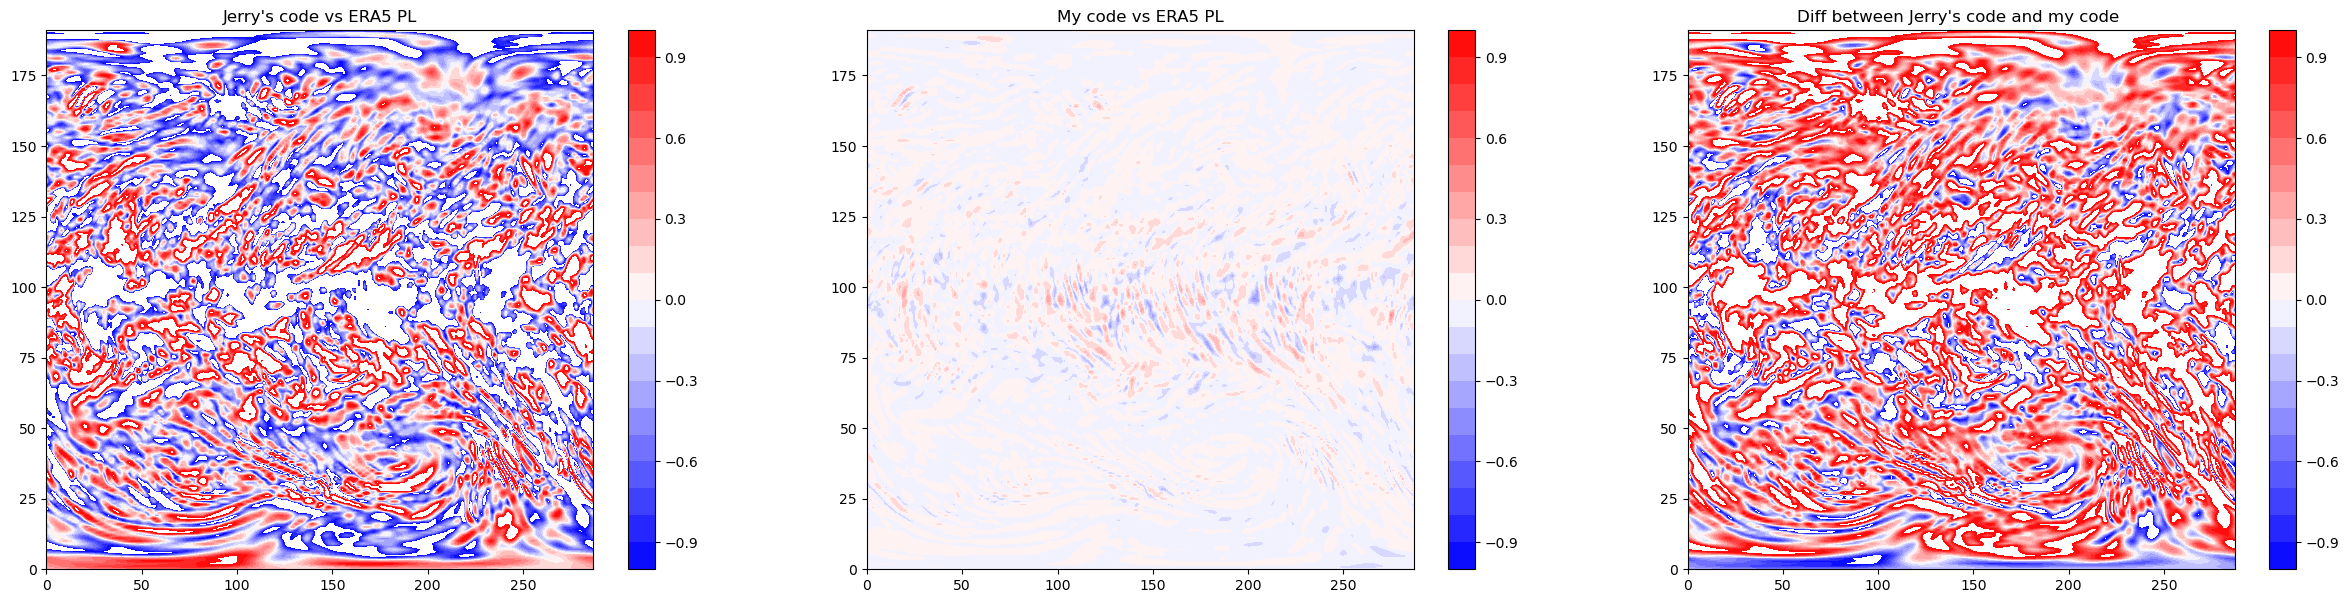

In [10]:
p=5
print(pl_era[p])
levs=np.linspace( -1,1,num=21) 

fig, ax = plt.subplots(1, 3, figsize=(30, 7))

# Flatten axs to easily access each subplot by index
ax = ax.flatten()
c0 = ax[0].contourf( (te0_pl-te_era_pl_f09)[0,p,:,:]  , cmap='bwr'  ,levels=levs )
ax[0].set_title("Jerry's code vs ERA5 PL")
plt.colorbar(c0,ax=ax[0])
c1 = ax[1].contourf( (te1_pl-te_era_pl_f09)[0,p,:,:]  , cmap='bwr'  ,levels=levs )
ax[1].set_title("My code vs ERA5 PL")
plt.colorbar(c1,ax=ax[1])
c2 = ax[2].contourf( (te1_pl-te0_pl)[0,p,:,:]  , cmap='bwr'  ,levels=levs )
plt.colorbar(c2,ax=ax[2])
ax[2].set_title("Diff between Jerry's code and my code ")



(0.0, 85.0)

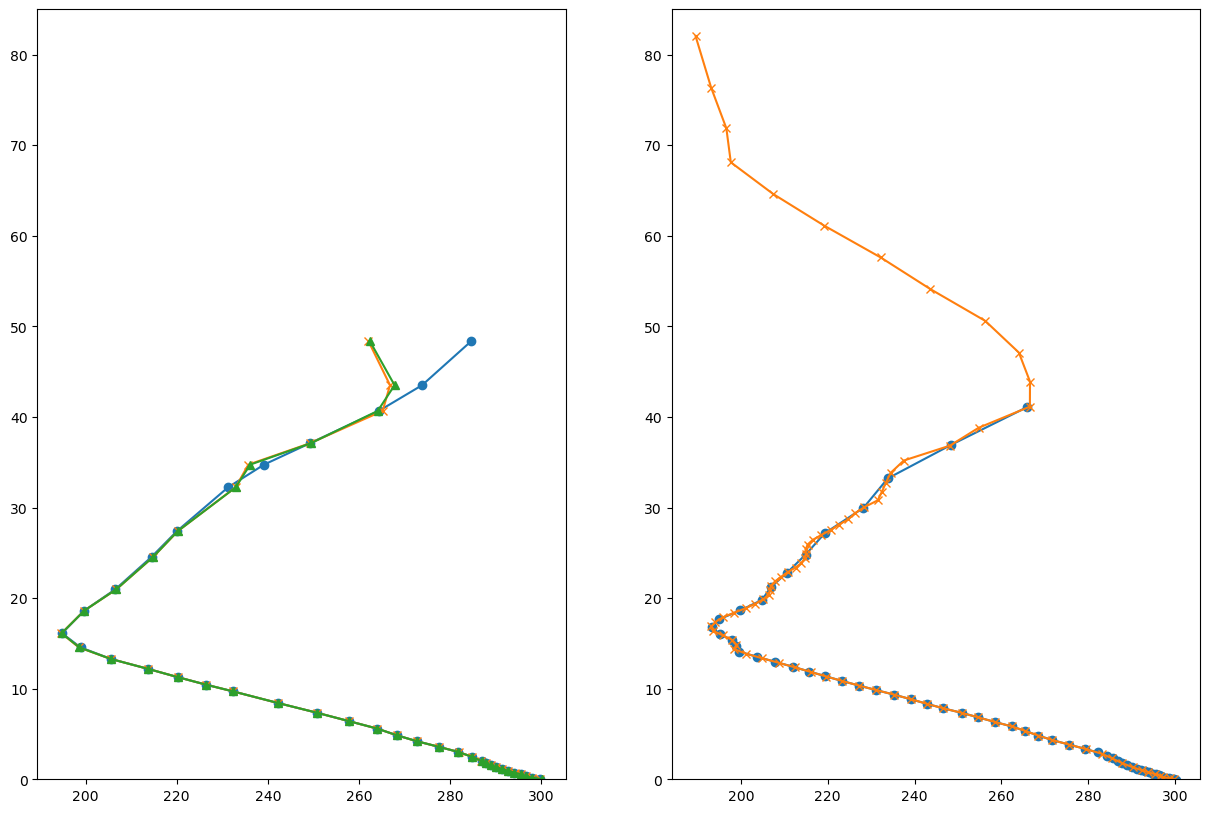

In [11]:
lpl_era=-7*np.log( pl_era/100_000. )

fig, ax = plt.subplots(1, 2, figsize=(15, 10))

y,x = 100,150

lpmid0 = -7*np.log( pmid0[0,:,y,x]/100_000. )
lpmid1 = -7*np.log( pmid1[0,:,y,x]/100_000. )
ax[0].plot( te0_pl[0,:,y,x],lpl_era ,'o-' )
ax[0].plot( te1_pl[0,:,y,x],lpl_era, 'x-')
ax[0].plot( te_era_pl_f09[0,:,y,x],lpl_era, '^-' )
ax[0].set_ylim(0,85)

ax[1].plot( te0[0,:,y,x],lpmid0, 'o-' )
ax[1].plot( te1[0,:,y,x],lpmid1, 'x-' )
ax[1].set_ylim(0,85)




In [12]:
#########################################################
# Get gridded model-level ERA5 data
#########################################################


era5dir = "/glade/campaign/collections/rda/data/ds633.6/e5.oper.an.ml/"

year,month,day,hour0 = 1997,11,1,0

monStr=str( year ).zfill(4)+str(month).zfill(2)

hour1=hour0+5
ymdh0=str( year ).zfill(4)+str(month).zfill(2)+str(day).zfill(2)+str(hour0).zfill(2)
ymdh1=str( year ).zfill(4)+str(month).zfill(2)+str(day).zfill(2)+str(hour1).zfill(2)
ymdh=ymdh0+'_'+ymdh1


wrkdir=era5dir+monStr+"/"
#Define all file names for later use in dask function
#-----------------------------------------------------
spfile= wrkdir + 'e5.oper.an.ml.128_134_sp.regn320sc.'+ymdh+'.nc'
tfile = wrkdir + 'e5.oper.an.ml.0_5_0_0_0_t.regn320sc.'+ymdh+'.nc'

T_ERA   = xr.open_mfdataset( tfile , data_vars='different', coords='different')
PS_ERA   = xr.open_mfdataset( spfile , data_vars='different', coords='different')

#################################################
# Extract ERA5 temperature and surface pressure.
#################################################
te_era = T_ERA.T.values
ps_era = PS_ERA.SP.values


###############################
# Extract a's and b's for
# both ERA5 and CAM.
# Also, calculate 'eta' vertical
# coordinate
##############################
am_era, bm_era = T_ERA.a_model.values/100_000. , T_ERA.b_model.values

eta_era = T_ERA.a_model.values/100_000. + T_ERA.b_model.values
eta_cam = X1.hyam.values + X1.hybm.values

